# Smart Spatial Geo-Dispatch Optimizer
## Smart Urban Services - Spatial AI Dispatch Engine
---
### Objectives:
1. Ingest provider GPS spatial telemetry across Sri Lankan hubs (Colombo, Kandy, Gampaha, Galle).
2. Compute spherical Haversine Geodesic Distance matrices.
3. Fit a K-Nearest Neighbors (KNN) spatial model for nearest provider ranking and ETA estimation.
4. Visualize worker trade clusters on 2D coordinates.
5. Export the trained spatial model to models/geo_dispatcher.pkl.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
import joblib

print('Spatial AI libraries imported successfully!')

Spatial AI libraries imported successfully!


## 1. Provider Spatial Coordinates Generation

In [2]:
p = os.path.abspath(os.getcwd())
AI_ROOT = p
while p != os.path.dirname(p):
    cand_ai = os.path.join(p, 'ai', 'data')
    if os.path.exists(cand_ai):
        AI_ROOT = os.path.join(p, 'ai')
        break
    cand = os.path.join(p, 'data')
    if os.path.exists(cand):
        AI_ROOT = p
        break
    p = os.path.dirname(p)

DATA_PROCESSED = os.path.join(AI_ROOT, 'data', 'processed')
MODELS_DIR = os.path.join(AI_ROOT, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(DATA_PROCESSED, exist_ok=True)

np.random.seed(42)
n_providers = 500

colombo_lat, colombo_lng = 6.9271, 79.8612
kandy_lat, kandy_lng = 7.2906, 80.6337

is_kandy = np.random.random(n_providers) < 0.45
lats = np.where(is_kandy, kandy_lat + np.random.normal(0, 0.05, n_providers), colombo_lat + np.random.normal(0, 0.06, n_providers))
lngs = np.where(is_kandy, kandy_lng + np.random.normal(0, 0.05, n_providers), colombo_lng + np.random.normal(0, 0.06, n_providers))

trades = ['plumbing', 'tree-cutting', 'painting', 'tech', 'cleaning', 'odd_jobs']
ratings = np.round(np.random.uniform(3.8, 5.0, n_providers), 1)
verified = np.random.choice([0, 1], n_providers, p=[0.3, 0.7])

df_prov = pd.DataFrame({
    'provider_id': [f'W-{i:04d}' for i in range(1, n_providers + 1)],
    'lat': np.round(lats, 4),
    'lng': np.round(lngs, 4),
    'trade': np.random.choice(trades, n_providers),
    'rating': ratings,
    'is_verified': verified
})

proc_spatial = os.path.join(DATA_PROCESSED, 'service_pricing', 'provider_spatial_telemetry.csv')
os.makedirs(os.path.dirname(proc_spatial), exist_ok=True)
df_prov.to_csv(proc_spatial, index=False)
df_prov.head()

,provider_id,lat,lng,trade,rating,is_verified
0,W-0001,7.3077,80.6988,cleaning,4.0,0
1,W-0002,6.9055,79.8866,painting,5.0,1
2,W-0003,6.9625,79.8328,cleaning,3.9,0
3,W-0004,6.9936,79.8603,tree-cutting,4.3,1
4,W-0005,7.2457,80.6567,painting,4.7,1


## 2. Spatial Clustering Visualization

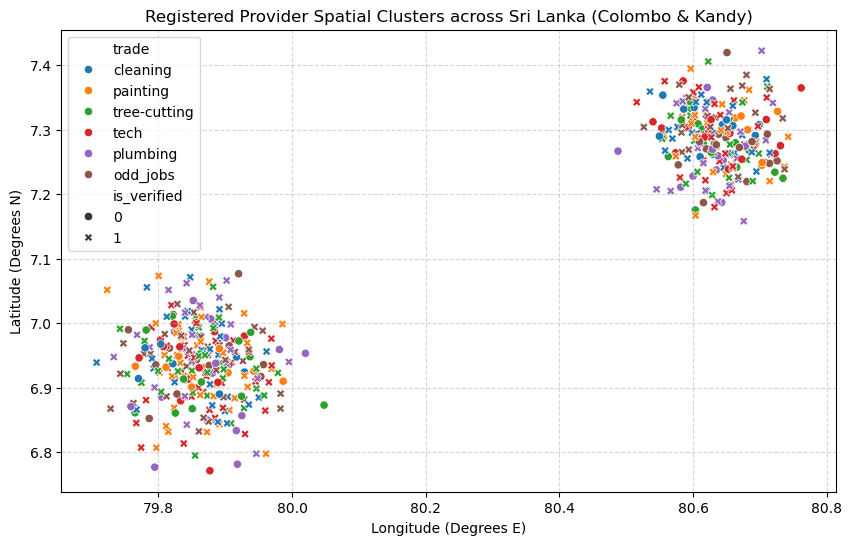

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_prov, x='lng', y='lat', hue='trade', style='is_verified', palette='tab10')
plt.title('Registered Provider Spatial Clusters across Sri Lanka (Colombo & Kandy)')
plt.xlabel('Longitude (Degrees E)')
plt.ylabel('Latitude (Degrees N)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 3. Fit K-Nearest Neighbors (KNN) Model & Export

In [4]:
coords_rad = np.radians(df_prov[['lat', 'lng']].values)
knn = NearestNeighbors(n_neighbors=5, metric='haversine')
knn.fit(coords_rad)

joblib.dump({'knn': knn, 'df': df_prov}, os.path.join(MODELS_DIR, 'geo_dispatcher.pkl'))
print('Trained KNN Dispatcher exported to models/geo_dispatcher.pkl!')

Trained KNN Dispatcher exported to models/geo_dispatcher.pkl!
